In [1]:
import sys
import os

functions_path = os.path.abspath(os.path.join('..', 'functions'))
if functions_path not in sys.path:
    sys.path.append(functions_path)

In [2]:
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt

# Import functions
from methods import rescaled_gamma_prior_mcmc, knn_prior_mcmc, kernel_ridge_cv

# set the random seed 
np.random.seed(2025)

In [3]:
def generate_figure_data(
    num,
    obj_name="obj4__",
    data_dir=None):

    if data_dir is None:
        raise ValueError("Please provide data_dir pointing to the image folder.")
    data_dir = Path(data_dir)
    data = np.zeros((num, 128, 128))
    for i in range(num):
        img_path = data_dir / f"{obj_name}{i}.png"
        data[i, :, :] = np.array(Image.open(img_path))
    return data

def cat_train_test(n_data, train_size, sigma_noise, data, f0, max_scale = 255):
    idx = np.arange(n_data)
    th = idx/n_data * 2* np.pi
    np.random.shuffle(idx)
    train_idx, test_idx = idx[:train_size], idx[train_size:]
    
    X = data[train_idx,:].reshape(train_size, -1)
    X = X/max_scale 
    tX = th[train_idx]
    Y_de_train = f0[train_idx]
    Y_train = Y_de_train + sigma_noise * np.random.randn(train_size)
    
    X_test = data[test_idx,:].reshape(n_data-train_size, -1)
    X_test = X_test/max_scale
    tX_test = th[test_idx]
    Y_de_test = f0[test_idx]
  
    return X, tX, X_test, tX_test,Y_de_train, Y_train ,Y_de_test

def cat_data_loader( *, n_data, train_size, sigmasq_0, data, f0):
    sigma_noise = np.sqrt(sigmasq_0)
    max_scale = 255.0
    X_train, tX_train, X_test, tX_test, Y_de_train, Y_train, Y_de_test = cat_train_test(
                    n_data = n_data, train_size=train_size, sigma_noise=sigma_noise,
                    data= data, f0=f0, max_scale=max_scale)
    # Algorithm does NOT need tX, tX_test
    return X_train, X_test, Y_train, Y_de_train, Y_de_test

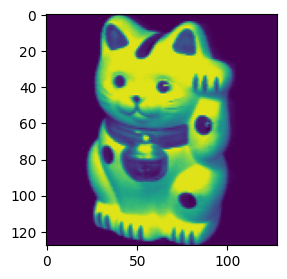

In [4]:
project_root = Path("..")          # demos/ → project_root
data_dir = project_root / "data" / "coil-20-proc"

n_data = 72

cat_data = generate_figure_data(num = n_data,
                            obj_name="obj4__",
                            data_dir=data_dir)
cat_f0 = np.cos(2 * np.pi * np.arange(0,n_data)/n_data)  #true response

# visualize data
fig = plt.figure(figsize=(4, 3))
plt.imshow(cat_data[3,:,:])
#plt.title("original")
plt.show()

In [5]:
# parameters for all methods

sigmasq_0 = 0.01 #Noise level
n_data = 72 #Data_size

data_loader_kwargs = dict(
    data= cat_data,
    f0=cat_f0
)

#grid_pos_param of marginal posterior of t
n_grid = 400
left_end = 200 # 10 ** -6
right_end = 20000
ls_grid_epsilon = np.linspace(left_end, right_end, n_grid)
grid_pos_tolerance = 10**(-10)

#MCMC params
mcmc_time = 3000
burn_in = 1000

replicas = 400
#replicas = 10
train_size_ls = [18,36,54]

In [6]:
#rescaled gamma prior GP
d = 1
a_0 = 1
b_0 = 1 

w_pos_means = []
w_pos_std = []
w_pos_test_means = []
w_pos_test_std = []
dict_log_grid_pos = {}
dict_ls_epsilon = {}

for train_size in train_size_ls:
    ls_w_pos,ls_w_pos_test,dict_log_grid_pos[train_size], dict_ls_epsilon[train_size] = \
                    rescaled_gamma_prior_mcmc(train_size, replicas, n_data, sigmasq_0,
                           n_grid,left_end,right_end, grid_pos_tolerance,
                           a_0, b_0, d, 
                           burn_in, mcmc_time,
                           data_loader= cat_data_loader, data_loader_kwargs=data_loader_kwargs)
    w_pos_means.append(np.mean(ls_w_pos))
    w_pos_std.append(np.std(ls_w_pos))
    w_pos_test_means.append(np.mean(ls_w_pos_test))
    w_pos_test_std.append(np.std(ls_w_pos_test))
    print(f"train_size {train_size}, IS error {np.mean(ls_w_pos)}, OS error {np.mean(ls_w_pos_test)}")

0 replica time: 0.24
proposal: 5.30e+02, start_point: 1837.59, err_in: 0.08, err_os: 0.16
1 replica time: 0.08
proposal: 6.31e+02, start_point: 2333.83, err_in: 0.11, err_os: 0.14
2 replica time: 0.08
proposal: 5.46e+02, start_point: 2085.71, err_in: 0.07, err_os: 0.10
3 replica time: 0.08
proposal: 5.78e+02, start_point: 1986.47, err_in: 0.11, err_os: 0.20
4 replica time: 0.09
proposal: 5.99e+02, start_point: 2036.09, err_in: 0.07, err_os: 0.16
5 replica time: 0.09
proposal: 5.06e+02, start_point: 1837.59, err_in: 0.10, err_os: 0.11
6 replica time: 0.09
proposal: 5.58e+02, start_point: 2036.09, err_in: 0.08, err_os: 0.17
7 replica time: 0.08
proposal: 6.57e+02, start_point: 2234.59, err_in: 0.09, err_os: 0.25
8 replica time: 0.08
proposal: 5.46e+02, start_point: 1986.47, err_in: 0.06, err_os: 0.09
9 replica time: 0.08
proposal: 5.50e+02, start_point: 1936.84, err_in: 0.10, err_os: 0.10
10 replica time: 0.08
proposal: 6.51e+02, start_point: 2333.83, err_in: 0.08, err_os: 0.20
11 replic

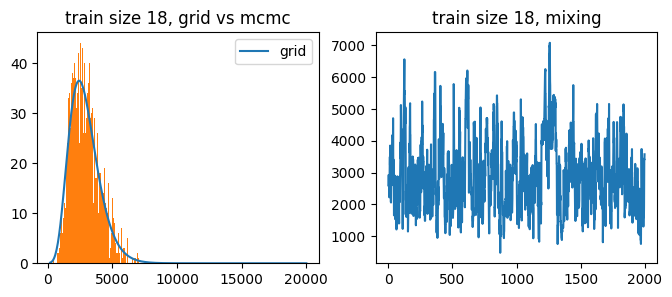

In [7]:
train_size = 18
# grid of marginal posterior of t
log_grid_pos = dict_log_grid_pos[train_size]
weight_pos = np.exp(log_grid_pos - np.max(log_grid_pos))
weight_pos = weight_pos/np.sum(weight_pos)
plt.figure(figsize=(8,3))
plt.subplot(121)
plt.plot(ls_grid_epsilon,weight_pos*(mcmc_time-burn_in),label = 'grid')
plt.title(f"train size {train_size}, grid vs mcmc")
plt.hist(dict_ls_epsilon[train_size][burn_in:],bins = ls_grid_epsilon)
plt.legend()
plt.subplot(122)
plt.plot(dict_ls_epsilon[train_size][burn_in:])
plt.title(f"train size {train_size}, mixing")
plt.show()

In [8]:
# knn prior GP
gamma1 = 0.25
gamma2 = 0.25
a_0 = 1
b_0 = 1

w_pos_knn_means = []
w_pos_knn_std = []
w_pos_knn_test_means = []
w_pos_knn_test_std = []
dict_Tn_count = {}
dict_log_grid_pos_knn = {}
dict_ls_epsilon_knn = {}

for train_size in train_size_ls:
    ls_w_pos_knn,ls_w_pos_knn_test, dict_Tn_count[train_size], dict_log_grid_pos_knn[train_size], dict_ls_epsilon_knn[train_size] \
     = knn_prior_mcmc(train_size, replicas, n_data,sigmasq_0,
                      n_grid, left_end,right_end,grid_pos_tolerance,
                      a_0,b_0, gamma1, gamma2, 
                      burn_in, mcmc_time,
                      data_loader=cat_data_loader,data_loader_kwargs=data_loader_kwargs,
                      v_hat_method='harmonic')
    w_pos_knn_means.append(np.mean(ls_w_pos_knn))
    w_pos_knn_std.append(np.std(ls_w_pos_knn))
    w_pos_knn_test_means.append(np.mean(ls_w_pos_knn_test))
    w_pos_knn_test_std.append(np.std(ls_w_pos_knn_test))
    print(f"train_size {train_size}, IS error {np.mean(ls_w_pos_knn)}, OS error {np.mean(ls_w_pos_knn_test)}")

0 replica time: 0.11, Tn_count 5
proposal: 6.55e+02, start_point: 2681.20, err_in: 0.07, err_os: 0.13
1 replica time: 0.10, Tn_count 25
proposal: 7.64e+02, start_point: 2830.08, err_in: 0.09, err_os: 0.27
2 replica time: 0.11, Tn_count 15
proposal: 5.10e+02, start_point: 1986.47, err_in: 0.10, err_os: 0.15
3 replica time: 0.11, Tn_count 10
proposal: 6.01e+02, start_point: 2333.83, err_in: 0.09, err_os: 0.30
4 replica time: 0.11, Tn_count 9
proposal: 6.23e+02, start_point: 2482.71, err_in: 0.09, err_os: 0.17
5 replica time: 0.11, Tn_count 18
proposal: 5.80e+02, start_point: 2383.46, err_in: 0.07, err_os: 0.10
6 replica time: 0.11, Tn_count 7
proposal: 5.64e+02, start_point: 2234.59, err_in: 0.05, err_os: 0.14
7 replica time: 0.10, Tn_count 1
proposal: 6.49e+02, start_point: 2681.20, err_in: 0.07, err_os: 0.20
8 replica time: 0.10, Tn_count 10
proposal: 5.74e+02, start_point: 2284.21, err_in: 0.09, err_os: 0.13
9 replica time: 0.10, Tn_count 12
proposal: 5.90e+02, start_point: 2433.08, e

In [9]:
#Sanity check
dict_Tn_count

{18: array([ 5., 25., 15., 10.,  9., 18.,  7.,  1., 10., 12.,  6., 10., 10.,
         7.,  7., 16., 10., 17., 12., 11.,  7., 17., 15., 10., 13., 19.,
         9.,  9., 11., 17., 11., 12.,  6., 31., 10.,  9., 29.,  7., 13.,
         9., 10., 16., 15., 10., 18., 19., 17.,  9., 15., 13.,  3.,  1.,
        10.,  6.,  4., 12.,  7., 14.,  6., 13., 12.,  8.,  7.,  7., 22.,
        33., 17., 14., 32., 14., 15., 18., 31., 20.,  9., 15., 15., 10.,
        13., 18.,  7.,  8., 11., 20., 38.,  5., 23., 16.,  8.,  8., 18.,
        21., 15., 14., 11., 24., 12.,  8., 14., 10., 10.,  8., 16., 15.,
        18., 16., 11., 14., 11., 18., 14., 17., 11., 20., 23.,  9., 15.,
         8., 14., 21.,  6., 11., 16., 12., 17., 14., 11.,  5., 15., 11.,
        13., 16.,  7., 14., 16., 15., 13.,  9.,  7.,  8., 10., 16., 16.,
        13., 14., 14., 33., 21., 12., 10., 15., 14., 15., 13., 12., 12.,
        11.,  9., 12., 13., 19.,  8.,  7., 23., 17., 14., 16., 16., 12.,
         8.,  9., 27.,  9., 10.,  6.,  8.,  6.,

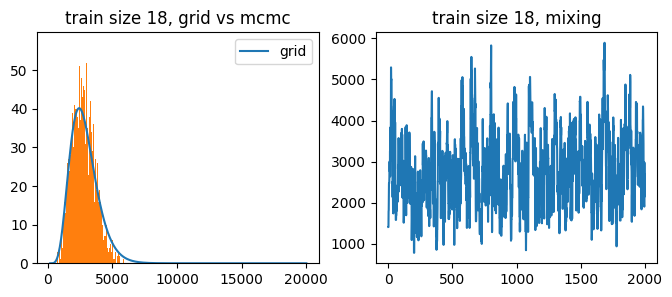

In [10]:
train_size = 18
# grid of marginal posterior of t
log_grid_pos_knn = dict_log_grid_pos_knn[train_size]
weight_pos = np.exp(log_grid_pos_knn - np.max(log_grid_pos_knn))
weight_pos = weight_pos/np.sum(weight_pos)
plt.figure(figsize=(8,3))
plt.subplot(121)
plt.plot(ls_grid_epsilon,weight_pos*(mcmc_time-burn_in),label = 'grid')
plt.title(f"train size {train_size}, grid vs mcmc")
plt.hist(dict_ls_epsilon_knn[train_size][burn_in:],bins = ls_grid_epsilon)
plt.legend()
plt.subplot(122)
plt.plot(dict_ls_epsilon_knn[train_size][burn_in:])
plt.title(f"train size {train_size}, mixing")
plt.show()

In [11]:
#kernel ridge cv
val_percent = 0.1

cv_means = []
cv_std = []
cv_test_means = []
cv_test_std = []
for train_size in train_size_ls:
    ls_kernel_ridge,ls_kernel_ridge_test,ls_single = kernel_ridge_cv(train_size, replicas,val_percent,n_data,sigmasq_0,
                           n_grid, left_end,right_end,
                           data_loader=cat_data_loader,data_loader_kwargs=data_loader_kwargs)
    
    cv_means.append(np.mean(ls_kernel_ridge))
    cv_std.append(np.std(ls_kernel_ridge))
    cv_test_means.append(np.mean(ls_kernel_ridge_test))
    cv_test_std.append(np.std(ls_kernel_ridge_test))
    print(f"train_size {train_size}, IS error {np.mean(ls_kernel_ridge)}, OS error {np.mean(ls_kernel_ridge_test)}")

0 replica time: 0.02
1 replica time: 0.02
2 replica time: 0.02
3 replica time: 0.02
4 replica time: 0.02
5 replica time: 0.02
6 replica time: 0.02
7 replica time: 0.02
8 replica time: 0.02
9 replica time: 0.02
10 replica time: 0.02
11 replica time: 0.02
12 replica time: 0.02
13 replica time: 0.02
14 replica time: 0.02
15 replica time: 0.02
16 replica time: 0.02
17 replica time: 0.02
18 replica time: 0.02
19 replica time: 0.02
20 replica time: 0.02
21 replica time: 0.02
22 replica time: 0.02
23 replica time: 0.02
24 replica time: 0.02
25 replica time: 0.02
26 replica time: 0.02
27 replica time: 0.02
28 replica time: 0.02
29 replica time: 0.02
30 replica time: 0.02
31 replica time: 0.02
32 replica time: 0.02
33 replica time: 0.02
34 replica time: 0.02
35 replica time: 0.02
36 replica time: 0.02
37 replica time: 0.02
38 replica time: 0.02
39 replica time: 0.02
40 replica time: 0.02
41 replica time: 0.02
42 replica time: 0.02
43 replica time: 0.02
44 replica time: 0.02
45 replica time: 0.0

In [12]:
def format_stats(means, stds, precision=4):
    means_fmt = [f"{m:.{precision}f}" for m in means]
    stds_fmt  = [f"{s:.{precision}f}" for s in stds]
    return ", ".join([f"{m} ± {s}" for m, s in zip(means_fmt, stds_fmt)])


print("\n========== TEST PERFORMANCE ==========")
print(f"KNN-MCMC        : {format_stats(w_pos_knn_test_means, w_pos_knn_test_std)}")
print(f"Rescaled-Gamma  : {format_stats(w_pos_test_means,     w_pos_test_std)}")
print(f"KernelRidge-CV  : {format_stats(cv_test_means,        cv_test_std)}")

print("\n========== TRAIN PERFORMANCE ==========")
print(f"KNN-MCMC        : {format_stats(w_pos_knn_means, w_pos_knn_std)}")
print(f"Rescaled-Gamma  : {format_stats(w_pos_means,     w_pos_std)}")
print(f"KernelRidge-CV  : {format_stats(cv_means,        cv_std)}")


========== TEST PERFORMANCE ==========
KNN-MCMC        : 0.1856 ± 0.0680, 0.0995 ± 0.0305, 0.0756 ± 0.0188
Rescaled-Gamma  : 0.1898 ± 0.0704, 0.0962 ± 0.0304, 0.0749 ± 0.0184
KernelRidge-CV  : 0.2274 ± 0.0915, 0.1092 ± 0.0355, 0.0810 ± 0.0241

========== TRAIN PERFORMANCE ==========
KNN-MCMC        : 0.0865 ± 0.0159, 0.0777 ± 0.0101, 0.0694 ± 0.0086
Rescaled-Gamma  : 0.0865 ± 0.0163, 0.0774 ± 0.0103, 0.0704 ± 0.0082
KernelRidge-CV  : 0.0856 ± 0.0167, 0.0774 ± 0.0134, 0.0688 ± 0.0129
